# Diagnostic Workflows with `DiagnosticsModule`

This notebook demonstrates the unified diagnostic interface for ProbPipe posteriors.

`DiagnosticsModule` collects MCMC diagnostics, predictive checks, LOO-PSIS, and sensitivity analysis into a single nested dict. The zero-config path requires only a fitted posterior:

```python
record = DiagnosticsModule.default().run(posterior)
record["mcmc"]["warnings"]   # [] = all passed
```

Users can extend it with their own diagnostic functions without touching the module internals.

**Sections**
1. Setup and model fitting
2. Zero-config MCMC diagnostics
3. Visual diagnostics — trace, rank, KDE plots
4. Posterior predictive checks via `DiagnosticsModule`
5. LOO-PSIS
6. Sensitivity analysis
7. Extending with user-defined diagnostics
8. Comparing diagnostics across model iterations

## 1. Setup

In [1]:
import warnings
warnings.filterwarnings('ignore', category=DeprecationWarning)
warnings.filterwarnings('ignore', category=FutureWarning)

import jax, jax.numpy as jnp, numpy as np, matplotlib.pyplot as plt
import pandas as pd
import tensorflow_probability.substrates.jax.glm as tfp_glm

from probpipe import (
    Record, Normal, ProductDistribution,
    GLMLikelihood, SimpleModel,
    condition_on, workflow_function,
)

from probpipe.diagnostics import DiagnosticsModule, loo, run_ppc

In [2]:
# ── Data ──────────────────────────────────────────────────────────────────────
df = pd.read_csv("../tutorials/data/horseshoe_crabs.csv")

@workflow_function
def prep_data(width, satellites) -> Record:
    width = np.asarray(width, dtype=np.float32)
    width_z = (width - np.mean(width)) / np.std(width)
    X = np.column_stack([np.ones(len(width)), width_z]).astype(np.float32)
    return Record(X=X, y=np.asarray(satellites, dtype=np.float32))

data = prep_data(df['width_cm'], df['satellites'])
print(data)

19:51:36.348 | INFO    | Flow run 'versed-lorikeet' - Beginning flow run 'versed-lorikeet' for flow 'prep_data_map'

19:51:36.350 | INFO    | Flow run 'versed-lorikeet' - View at http://127.0.0.1:4200/runs/flow-run/cc35ca46-5f69-40dc-b3ea-c3bc7103d244

19:51:36.358 | INFO    | Task run 'prep_data-d1d' - Finished in state Completed()

19:51:36.370 | INFO    | Flow run 'versed-lorikeet' - Finished in state Completed()

Record(X=array(shape=(172, 2)), y=array(shape=(172,)))


In [3]:
# ── Poisson model ─────────────────────────────────────────────────────────────
lik_poisson = GLMLikelihood(tfp_glm.Poisson(), data["X"])
prior_poisson = ProductDistribution(
    intercept=Normal(loc=0.0, scale=jnp.sqrt(5.0), name="intercept"),
    slope=Normal(loc=0.0, scale=jnp.sqrt(5.0), name="slope"),
)
model_poisson = SimpleModel(prior_poisson, lik_poisson, name='poisson')

posterior_poisson = condition_on(model_poisson, data["y"])
print(posterior_poisson.source)

19:51:36.432 | INFO    | Flow run 'aloof-marten' - Beginning flow run 'aloof-marten' for flow 'condition_on_map'

19:51:36.433 | INFO    | Flow run 'aloof-marten' - View at http://127.0.0.1:4200/runs/flow-run/733a1c4c-50bd-41bc-82ed-06bd20bc0785

19:51:38.136 | INFO    | Task run 'condition_on-60d' - Finished in state Completed()

19:51:38.147 | INFO    | Flow run 'aloof-marten' - Finished in state Completed()

Provenance('tfp_nuts', parents=[product(intercept,slope)])


In [4]:
# ── Negative binomial model ───────────────────────────────────────────────────
lik_nb = GLMLikelihood(tfp_glm.NegativeBinomial(), data["X"])
prior_nb = ProductDistribution(
    intercept=Normal(loc=0.0, scale=jnp.sqrt(5.0), name="intercept"),
    slope=Normal(loc=0.0, scale=jnp.sqrt(5.0), name="slope"),
)
model_nb = SimpleModel(prior_nb, lik_nb, name='negbin')

posterior_nb = condition_on(model_nb, data["y"])
print(posterior_nb.source)

19:51:38.178 | INFO    | Flow run 'lyrical-beagle' - Beginning flow run 'lyrical-beagle' for flow 'condition_on_map'

19:51:38.178 | INFO    | Flow run 'lyrical-beagle' - View at http://127.0.0.1:4200/runs/flow-run/b9ca8b60-fb5d-42fd-bfc2-ba48cf438e8c

19:51:39.336 | INFO    | Task run 'condition_on-a4d' - Finished in state Completed()

19:51:39.345 | INFO    | Flow run 'lyrical-beagle' - Finished in state Completed()

Provenance('tfp_nuts', parents=[product(intercept,slope)])


## 2. Zero-config MCMC diagnostics

`DiagnosticsModule.default()` wraps R-hat, ESS (bulk + tail), and MCSE. Call `.run(posterior)` to get the full nested result. No configuration required.

In [5]:
import inspect
from probpipe.validation._predictive_check import predictive_check
import typing
hints = typing.get_type_hints(predictive_check.func if hasattr(predictive_check, 'func') else predictive_check._func)
print(hints.get('distribution'))

<class 'probpipe.core._distribution_base.Distribution'>


In [6]:
diag = DiagnosticsModule.default()
record = diag.run(posterior_nb)

# The top-level key is "mcmc" — the built-in diagnostic
print(record.keys())

19:51:39.378 | INFO    | Flow run 'silver-limpet' - Beginning flow run 'silver-limpet' for flow 'DiagnosticsModule.run_map'

19:51:39.379 | INFO    | Flow run 'silver-limpet' - View at http://127.0.0.1:4200/runs/flow-run/358ca36e-163e-498c-912b-077187c5c632

19:51:39.420 | INFO    | Task run 'DiagnosticsModule.run-143' - Beginning subflow run 'jumping-millipede' for flow 'mcmc_summary_map'

19:51:39.420 | INFO    | Flow run 'jumping-millipede' - View at http://127.0.0.1:4200/runs/flow-run/5a415a2a-4de6-4249-97b3-59d458f496a2

Shape validation failed: input_shape: (1, 1000), minimum_shape: (chains=2, draws=4)


19:51:39.427 | INFO    | Task run 'mcmc_summary-e06' - Finished in state Completed()

19:51:39.437 | INFO    | Flow run 'jumping-millipede' - Finished in state Completed()

19:51:39.439 | INFO    | Task run 'DiagnosticsModule.run-143' - Finished in state Completed()

19:51:39.446 | INFO    | Flow run 'silver-limpet' - Finished in state Completed()

In [7]:
mcmc = record["mcmc"]

print("R-hat:     ", mcmc["rhat"])
print("ESS bulk:  ", mcmc["ess_bulk"])
print("ESS tail:  ", mcmc["ess_tail"])
print("MCSE mean: ", mcmc["mcse_mean"])
print()
if mcmc["warnings"]:
    for w in mcmc["warnings"]:
        print("⚠", w)
else:
    print("✓ All MCMC diagnostics passed.")

R-hat:      {'intercept': nan, 'slope': nan}
ESS bulk:   {'intercept': 690.9350359490843, 'slope': 781.2520128492515}
ESS tail:   {'intercept': 635.0665195379804, 'slope': 657.7236016891927}
MCSE mean:  {'intercept': 0.004014579904090084, 'slope': 0.004310765883363199}

✓ All MCMC diagnostics passed.


In [8]:
# Individual methods are also available on the module
rhat_result = diag.rhat(posterior_nb)
print("R-hat (intercept):", rhat_result["rhat"]["intercept"])

ess_result = diag.ess(posterior_nb)
print("ESS bulk (slope): ", ess_result["ess_bulk"]["slope"])

19:51:41.694 | INFO    | Flow run 'resolute-millipede' - Beginning flow run 'resolute-millipede' for flow 'DiagnosticsModule.rhat_map'

19:51:41.695 | INFO    | Flow run 'resolute-millipede' - View at http://127.0.0.1:4200/runs/flow-run/befbd4cd-02f1-498d-a44d-9ba50c15a1bb

19:51:41.739 | INFO    | Task run 'DiagnosticsModule.rhat-9b3' - Beginning subflow run 'daffodil-rook' for flow 'compute_rhat_map'

19:51:41.740 | INFO    | Flow run 'daffodil-rook' - View at http://127.0.0.1:4200/runs/flow-run/19bb1e62-d3e8-4dad-be36-9fe437f2145d

/Users/ylim2/miniconda3/envs/probpipe/lib/python3.13/site-packages/prefect/task_engine.py:1030: UserWarning: R-hat requires at least 2 chains for a meaningful result. Run condition_on with num_chains >= 2.
  result = call_with_parameters(self.task.fn, parameters)


...

19:51:41.829 | INFO    | Task run 'compute_ess-bdc' - Finished in state Completed()

19:51:41.840 | INFO    | Flow run 'honest-wildebeest' - Finished in state Completed()

19:51:41.841 | INFO    | Task run 'DiagnosticsModule.ess-452' - Finished in state Completed()

19:51:41.865 | INFO    | Flow run 'invaluable-chinchilla' - Finished in state Completed()

ESS bulk (slope):  781.2520128492515


## 3. Visual diagnostics

Trace, rank, and KDE plots are available as individual methods or all-at-once via `plot_all`.

19:51:41.891 | INFO    | Flow run 'foamy-earthworm' - Beginning flow run 'foamy-earthworm' for flow 'DiagnosticsModule.trace_plot_map'

19:51:41.892 | INFO    | Flow run 'foamy-earthworm' - View at http://127.0.0.1:4200/runs/flow-run/b31657dd-2f8d-4add-ba8d-1e368124ce48

19:51:41.925 | INFO    | Task run 'DiagnosticsModule.trace_plot-a06' - Beginning subflow run 'discreet-stoat' for flow 'plot_trace_map'

19:51:41.926 | INFO    | Flow run 'discreet-stoat' - View at http://127.0.0.1:4200/runs/flow-run/57dac929-e4a9-461f-8a7f-b8c22bbfef3d

19:51:41.985 | INFO    | Task run 'plot_trace-066' - Finished in state Completed()

19:51:41.994 | INFO    | Flow run 'discreet-stoat' - Finished in state Completed()

19:51:41.995 | INFO    | Task run 'DiagnosticsModule.trace_plot-a06' - Finished in state Completed()

19:51:42.002 | INFO    | Flow run 'foamy-earthworm' - Finished in state Completed()

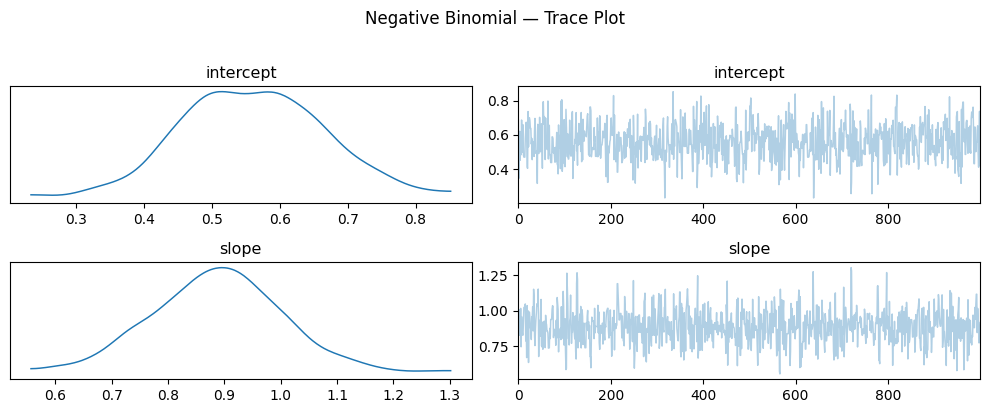

In [9]:
# Trace plot — well-mixed chains look like horizontal fuzzy caterpillars
fig = diag.trace_plot(posterior_nb, title="Negative Binomial — Trace Plot")["fig"]
plt.show()

19:51:42.077 | INFO    | Flow run 'heavy-duck' - Beginning flow run 'heavy-duck' for flow 'DiagnosticsModule.rank_plot_map'

19:51:42.077 | INFO    | Flow run 'heavy-duck' - View at http://127.0.0.1:4200/runs/flow-run/482f9c0b-7495-4999-979c-3b10a5208b85

19:51:44.001 | INFO    | Task run 'DiagnosticsModule.rank_plot-f71' - Beginning subflow run 'aquamarine-angelfish' for flow 'plot_rank_map'

19:51:44.002 | INFO    | Flow run 'aquamarine-angelfish' - View at http://127.0.0.1:4200/runs/flow-run/27af190e-956c-40f7-9fe8-487c86467b65

19:51:44.036 | INFO    | Task run 'plot_rank-284' - Finished in state Completed()

19:51:44.065 | INFO    | Flow run 'aquamarine-angelfish' - Finished in state Completed()

19:51:44.066 | INFO    | Task run 'DiagnosticsModule.rank_plot-f71' - Finished in state Completed()

19:51:44.074 | INFO    | Flow run 'heavy-duck' - Finished in state Completed()

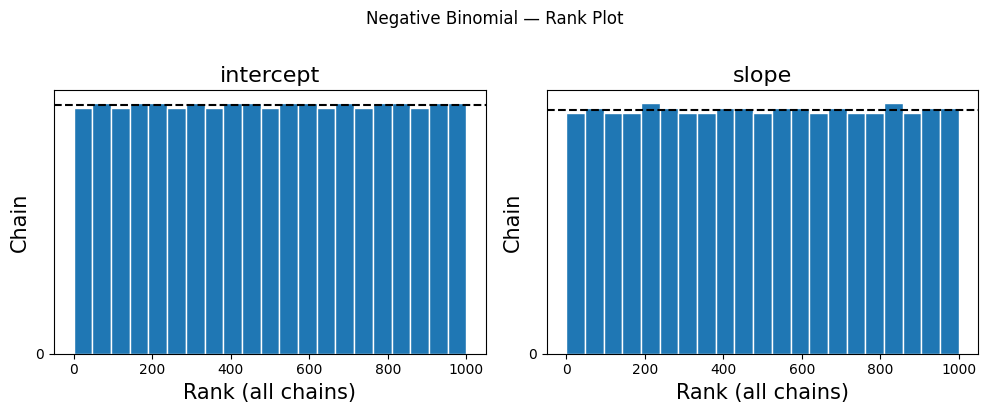

In [10]:
# Rank plot — more sensitive than trace plots for subtle convergence failures
fig = diag.rank_plot(posterior_nb, title="Negative Binomial — Rank Plot")["fig"]
plt.show()

19:51:44.133 | INFO    | Flow run 'important-peacock' - Beginning flow run 'important-peacock' for flow 'DiagnosticsModule.kde_plot_map'

19:51:44.133 | INFO    | Flow run 'important-peacock' - View at http://127.0.0.1:4200/runs/flow-run/5ce2c673-b6ff-4ee0-8f54-33b6bb5ece54

19:51:44.178 | INFO    | Task run 'DiagnosticsModule.kde_plot-3bc' - Beginning subflow run 'xanthic-squirrel' for flow 'plot_kde_map'

19:51:44.179 | INFO    | Flow run 'xanthic-squirrel' - View at http://127.0.0.1:4200/runs/flow-run/1d091b05-ecd8-484d-89a4-e693b310b2cb

19:51:44.810 | INFO    | Task run 'plot_kde-436' - Finished in state Completed()

19:51:44.821 | INFO    | Flow run 'xanthic-squirrel' - Finished in state Completed()

19:51:44.822 | INFO    | Task run 'DiagnosticsModule.kde_plot-3bc' - Finished in state Completed()

19:51:44.830 | INFO    | Flow run 'important-peacock' - Finished in state Completed()

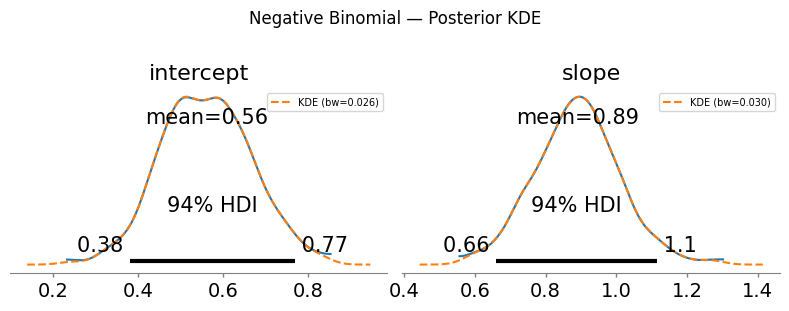

In [11]:
# KDE plot — marginal posterior density with HDI shading
fig = diag.kde_plot(
    posterior_nb,
    credible_interval=0.94,
    point_estimate="mean",
    title="Negative Binomial — Posterior KDE",
)["fig"]
plt.show()

19:51:44.886 | INFO    | Flow run 'delectable-mastodon' - Beginning flow run 'delectable-mastodon' for flow 'DiagnosticsModule.plot_all_map'

19:51:44.886 | INFO    | Flow run 'delectable-mastodon' - View at http://127.0.0.1:4200/runs/flow-run/17f8622a-9572-47ae-b693-5121acf8c211

19:51:44.922 | INFO    | Task run 'DiagnosticsModule.plot_all-ec6' - Beginning subflow run 'liberal-asp' for flow 'plot_trace_map'

19:51:44.923 | INFO    | Flow run 'liberal-asp' - View at http://127.0.0.1:4200/runs/flow-run/2ccf2cc6-293f-4cda-9f9a-e2209468adba

19:51:44.961 | INFO    | Task run 'plot_trace-e0b' - Finished in state Completed()

...

19:51:45.076 | INFO    | Flow run 'ivory-toucanet' - View at http://127.0.0.1:4200/runs/flow-run/fa0d421a-1af2-4a1f-ae53-6355d0d0ed9f

19:51:45.104 | INFO    | Task run 'plot_kde-07c' - Finished in state Completed()

19:51:45.115 | INFO    | Flow run 'ivory-toucanet' - Finished in state Completed()

19:51:45.116 | INFO    | Task run 'DiagnosticsModule.plot_all-ec6' - Finished in state Completed()

19:51:45.124 | INFO    | Flow run 'delectable-mastodon' - Finished in state Completed()

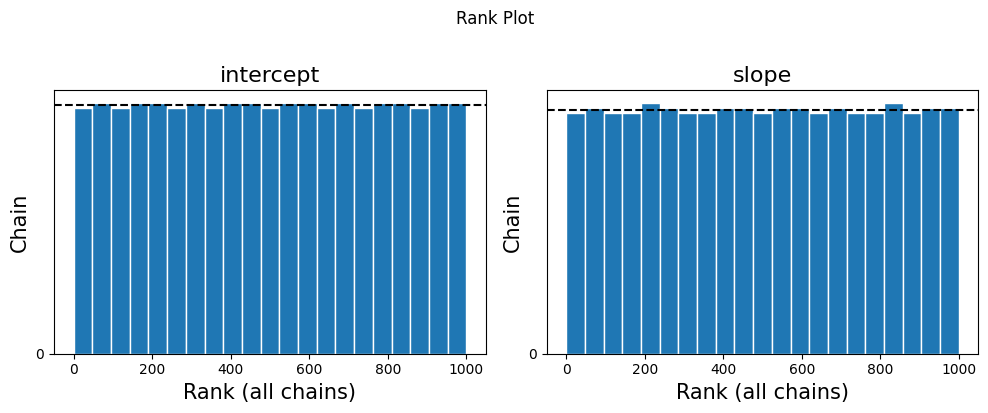

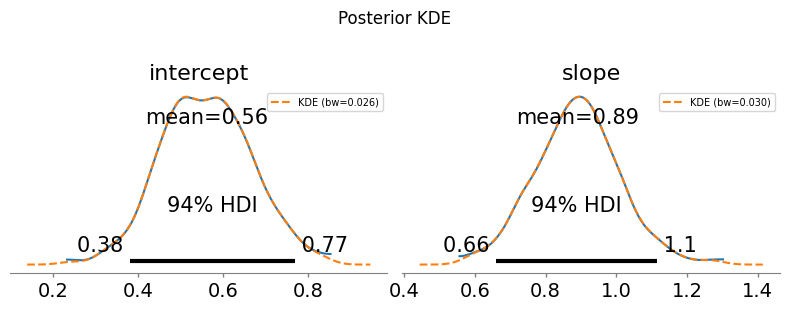

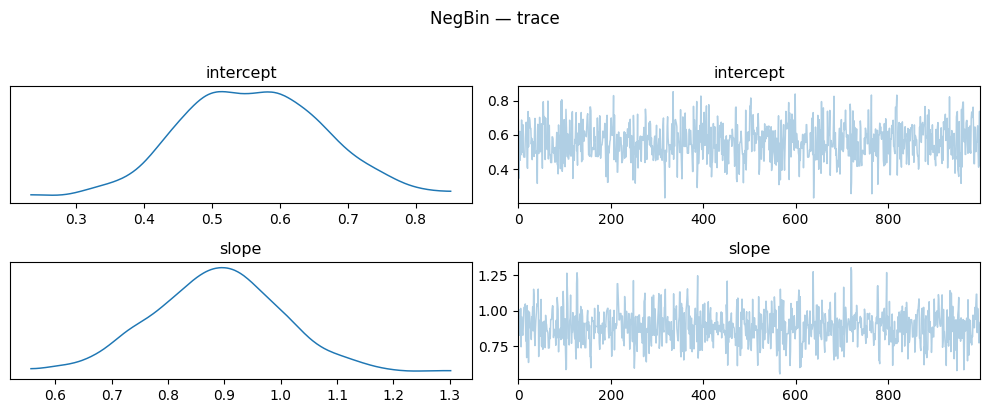

<Figure size 640x480 with 0 Axes>

<Figure size 640x480 with 0 Axes>

In [12]:
# All three plots in one call
plots = diag.plot_all(posterior_nb)
for name, fig in plots.items():
    fig.suptitle(f"NegBin — {name}", y=1.02)
    plt.figure(fig.number)
    plt.show()

## 4. Posterior predictive checks via `DiagnosticsModule`

`run_ppc` accepts one or more test functions and returns results keyed by function name.

**Important:** Pass the posterior distribution object (e.g. `posterior_nb`) directly — not draws or samples. The `predictive_check` task internally calls `._sample()` on the distribution, so it must receive the distribution itself, not a resolved `NumericRecord`.

In [13]:
var_mean_ratio = lambda d: float(jnp.var(d) / jnp.maximum(jnp.mean(d), 1e-6))
var_mean_ratio.__name__ = "var_mean_ratio"

zero_fraction = lambda d: float(jnp.mean(d == 0))
zero_fraction.__name__ = "zero_fraction"

# Pass the posterior distribution object directly — not posterior.draws()
ppc = run_ppc(
    posterior_nb,
    test_fns=[var_mean_ratio, zero_fraction],
    observed_data=data["y"],
    generative_likelihood=lik_nb,
    n_replications=500,
)

for name, result in ppc.items():
    print(f"{name}: observed={result['observed_statistic']:.3f}, p={result['p_value']:.3f}")

19:51:45.250 | INFO    | Flow run 'jolly-porcupine' - Beginning flow run 'jolly-porcupine' for flow 'run_ppc_map'

19:51:45.251 | INFO    | Flow run 'jolly-porcupine' - View at http://127.0.0.1:4200/runs/flow-run/25bc8b6e-2708-43f7-91cd-cfd35c8bb776

19:51:45.300 | INFO    | Task run 'run_ppc-ca1' - Beginning subflow run 'monumental-kangaroo' for flow 'predictive_check_map'

19:51:45.301 | INFO    | Flow run 'monumental-kangaroo' - View at http://127.0.0.1:4200/runs/flow-run/d7377fe1-d0fc-4ad0-a539-bce07a6cfb85

/Users/ylim2/miniconda3/envs/probpipe/lib/python3.13/site-packages/tensorflow_probability/python/internal/backend/jax/random_generators.py:136: UserWarning: Explicitly requested dtype float64 is not available, and will be truncated to dtype float32. To enable more dtypes, set the jax_enable_x64 configuration option or the JAX_ENABLE_X64 shell environment variable. See https://github.com/jax-ml/jax#current-gotchas for more.
  samps = jaxrand.gamma(


...

19:51:46.703 | INFO    | Task run 'predictive_check-217' - Finished in state Completed()

19:51:46.715 | INFO    | Flow run 'refreshing-pegasus' - Finished in state Completed()

19:51:46.716 | INFO    | Task run 'run_ppc-ca1' - Finished in state Completed()

19:51:46.723 | INFO    | Flow run 'jolly-porcupine' - Finished in state Completed()

var_mean_ratio: observed=4.141, p=0.982
zero_fraction: observed=0.465, p=0.034


In [14]:
# Add PPC as a user diagnostic so it travels with the module's run() record
def my_ppc(posterior):
    # posterior is the distribution object — passed through as-is
    result = run_ppc(
        posterior,
        test_fns=[var_mean_ratio, zero_fraction],
        observed_data=data["y"],
        generative_likelihood=lik_nb,
    )
    return {
        name: {"p_value": r["p_value"], "observed": r["observed_statistic"]}
        for name, r in result.items()
    }

diag_with_ppc = diag.with_diagnostic(ppc=my_ppc)
record2 = diag_with_ppc.run(posterior_nb)

print(record2.keys())
print("PPC p-values:", record2["ppc"])

19:51:46.754 | INFO    | Flow run 'fanatic-giraffe' - Beginning flow run 'fanatic-giraffe' for flow 'DiagnosticsModule.run_map'

19:51:46.755 | INFO    | Flow run 'fanatic-giraffe' - View at http://127.0.0.1:4200/runs/flow-run/857b8b38-cd9d-43d8-93f1-bcf639eb6989

19:51:46.792 | INFO    | Task run 'DiagnosticsModule.run-369' - Beginning subflow run 'clever-doberman' for flow 'mcmc_summary_map'

19:51:46.793 | INFO    | Flow run 'clever-doberman' - View at http://127.0.0.1:4200/runs/flow-run/e18c91d6-4753-4087-8d8f-789772baf0a4

19:51:46.799 | INFO    | Task run 'mcmc_summary-cec' - Finished in state Completed()

...

19:51:47.443 | INFO    | Task run 'run_ppc-6a3' - Finished in state Completed()

19:51:47.463 | INFO    | Flow run 'impetuous-mongoose' - Finished in state Completed()

19:51:47.464 | INFO    | Task run 'DiagnosticsModule.run-369' - Finished in state Completed()

19:51:47.472 | INFO    | Flow run 'fanatic-giraffe' - Finished in state Completed()

PPC p-values: {'var_mean_ratio': {'p_value': 0.964, 'observed': 4.140847682952881}, 'zero_fraction': {'p_value': 0.034, 'observed': 0.4651162624359131}}


## 5. LOO-PSIS

Leave-one-out cross-validation estimates out-of-sample predictive accuracy without re-fitting the model. Pareto-k values flag observations the model struggles to predict.

`loo` requires pointwise log likelihood values computed from posterior draws.

In [15]:
import jax.numpy as jnp

draws_nb = posterior_nb.draws()
n_total  = posterior_nb.num_chains * posterior_nb.num_draws

X = jnp.asarray(data["X"])   # (n_obs, p)
y = jnp.asarray(data["y"])   # (n_obs,)

log_lik_nb = np.array([
    np.asarray(lik_nb.family.log_prob(
        y,
        X @ jnp.array([draws_nb["intercept"][i], draws_nb["slope"][i]])
    ))
    for i in range(n_total)
])  # shape (n_total, n_obs)

In [16]:
loo_result = loo(posterior_nb, log_likelihood=log_lik_nb)

print(f"ELPD-LOO: {loo_result['elpd_loo']:.2f} (SE {loo_result['se']:.2f})")
print(f"LOO-IC:   {loo_result['looic']:.2f}")
print(f"p_loo:    {loo_result['p_loo']:.2f}")
print()
print("Pareto-k bucket counts:", loo_result["pareto_k"])

if loo_result["warnings"]:
    for w in loo_result["warnings"]:
        print("⚠", w)
else:
    print("✓ All Pareto-k values below 0.7.")

19:51:54.765 | INFO    | Flow run 'tangible-oxpecker' - Beginning flow run 'tangible-oxpecker' for flow 'loo_map'

19:51:54.766 | INFO    | Flow run 'tangible-oxpecker' - View at http://127.0.0.1:4200/runs/flow-run/d11be7d6-0d20-4f17-92a7-5f7a6e3b44f9

19:51:54.804 | INFO    | Task run 'loo-b24' - Finished in state Completed()

19:51:54.816 | INFO    | Flow run 'tangible-oxpecker' - Finished in state Completed()

ELPD-LOO: -320.74 (SE 16.23)
LOO-IC:   641.48
p_loo:    2.17

Pareto-k bucket counts: {'good': 172, 'ok': 0, 'bad': 0, 'very_bad': 0}
✓ All Pareto-k values below 0.7.


In [ ]:
# Add LOO as a user diagnostic
def my_loo(posterior):
    draws = posterior.draws()
    n = np.asarray(draws["intercept"]).shape[-1]
    log_lik = np.array([
        lik_nb.log_likelihood(
            params=np.array([draws["intercept"][i], draws["slope"][i]]),
            data=data["y"],
            pointwise=True,
        )
        for i in range(n)
    ])
    result = loo(posterior, log_likelihood=log_lik)
    return {
        "elpd_loo": result["elpd_loo"],
        "looic":    result["looic"],
        "se":       result["se"],
        "pareto_k": result["pareto_k"],
        "warnings": result["warnings"],
    }

diag_full = diag_with_ppc.with_diagnostic(loo=my_loo)
record3   = diag_full.run(posterior_nb)

print(record3.keys())
# Add LOO as a user diagnostic
def my_loo(posterior):
    result = loo(posterior, log_likelihood=log_lik_nb)
    return {
        "elpd_loo": result["elpd_loo"],
        "looic":    result["looic"],
        "se":       result["se"],
        "pareto_k": result["pareto_k"],
        "warnings": result["warnings"],
    }

diag_full = diag_with_ppc.with_diagnostic(loo=my_loo)
record3   = diag_full.run(posterior_nb)

print(record3.keys())
print("ELPD-LOO:", record3["loo"]["elpd_loo"])

19:51:54.855 | INFO    | Flow run 'black-cheetah' - Beginning flow run 'black-cheetah' for flow 'DiagnosticsModule.run_map'

19:51:54.856 | INFO    | Flow run 'black-cheetah' - View at http://127.0.0.1:4200/runs/flow-run/4efe6886-13a4-48f3-975c-ebd2b229d818

19:51:54.912 | INFO    | Task run 'DiagnosticsModule.run-b04' - Beginning subflow run 'augmented-axolotl' for flow 'mcmc_summary_map'

19:51:54.913 | INFO    | Flow run 'augmented-axolotl' - View at http://127.0.0.1:4200/runs/flow-run/57e099c2-0285-485f-bb8f-eaa260a76b74

19:51:54.920 | INFO    | Task run 'mcmc_summary-e08' - Finished in state Completed()

...

19:51:57.374 | INFO    | Task run 'run_ppc-91a' - Finished in state Completed()

19:51:57.386 | INFO    | Flow run 'busy-hyena' - Finished in state Completed()

19:51:57.388 | INFO    | Task run 'DiagnosticsModule.run-b04' - Finished in state Completed()

19:51:57.396 | INFO    | Flow run 'black-cheetah' - Finished in state Completed()

KeyError: 'elpd_loo'

## 6. Sensitivity analysis

Two modes are available:
- **Prior sensitivity** — compare posteriors fitted under different prior specs
- **Power-scale sensitivity** — local gradient of posterior summaries with respect to prior/likelihood scaling; no refitting needed

In [ ]:
from probpipe.diagnostics import prior_sensitivity, power_scale_sensitivity

# ── Prior sensitivity: fit under a tighter prior and compare ─────────────────
prior_tight = ProductDistribution(
    intercept=Normal(loc=0.0, scale=0.5, name="intercept"),
    slope=Normal(loc=0.0, scale=0.5, name="slope"),
)
model_tight = SimpleModel(prior_tight, lik_nb, name='negbin_tight')
posterior_tight = condition_on(model_tight, data["y"])

sensitivity = prior_sensitivity(
    posteriors={
        "weakly_informative": posterior_nb,
        "tight":              posterior_tight,
    },
    baseline="weakly_informative",
    kl_threshold=0.1,
)

print("Baseline:", sensitivity["baseline"])
print("Comparison:")
for label, stats in sensitivity["comparisons"].items():
    print(f"  {label}:")
    for var, metrics in stats.items():
        print(f"    {var}: mean_shift={metrics['mean_shift']:.4f}, KL={metrics['kl_divergence']:.4f}")

if sensitivity["warnings"]:
    for w in sensitivity["warnings"]:
        print("⚠", w)
else:
    print("✓ Low prior sensitivity — posterior is robust to prior choice.")

In [ ]:
# ── Power-scale sensitivity: no refitting required ───────────────────────────
draws_nb = posterior_nb.draws()
n_draws  = np.asarray(draws_nb["intercept"]).shape[-1]

# Per-draw log prior — use .draws() here, not the distribution object
log_prior = np.array([
    float(prior_nb.log_density(np.array([draws_nb["intercept"][i], draws_nb["slope"][i]])))
    for i in range(n_draws)
])

ps = power_scale_sensitivity(
    posterior_nb,
    log_likelihood=log_lik_nb,
    log_prior=log_prior,
    lower=0.5, upper=2.0, n_steps=15,
)

for var in ["intercept", "slope"]:
    prior_s = ps["prior_sensitivity"][var]
    lik_s   = ps["likelihood_sensitivity"][var]
    print(f"{var}:")
    print(f"  prior sensitivity:      d(mean)/d(alpha) = {prior_s['sensitivity']:.4f}  high={prior_s['high_sensitivity']}")
    print(f"  likelihood sensitivity: d(mean)/d(alpha) = {lik_s['sensitivity']:.4f}  high={lik_s['high_sensitivity']}")

if ps["warnings"]:
    for w in ps["warnings"]:
        print("⚠", w)
else:
    print("✓ No high sensitivity detected.")

In [ ]:
# Visualise power-scale sensitivity curves
alpha_grid = ps["alpha_grid"]
fig, axes = plt.subplots(1, 2, figsize=(10, 3.5))

for ax, var in zip(axes, ["intercept", "slope"]):
    prior_means = ps["prior_sensitivity"][var]["means"]
    lik_means   = ps["likelihood_sensitivity"][var]["means"]
    ax.plot(alpha_grid, prior_means, label="prior scaling", color="steelblue")
    ax.plot(alpha_grid, lik_means,   label="likelihood scaling", color="darkorange")
    ax.axvline(1.0, color="gray", ls="--", lw=0.8, label="alpha=1")
    ax.set(xlabel="alpha", ylabel=f"posterior mean ({var})", title=var)
    ax.legend(fontsize=8)

plt.suptitle("Power-scale sensitivity curves", y=1.02)
plt.tight_layout()
plt.show()

## 7. Extending with user-defined diagnostics

Any callable that accepts a posterior and returns a dict can be registered. `with_diagnostic` returns a new module — the original is unchanged.

In [ ]:
# A custom diagnostic: posterior mean and std for a quick summary
def posterior_summary(posterior) -> dict:
    # Use .draws() to access resolved parameter arrays
    draws = posterior.draws()
    return {
        var: {
            "mean": float(np.mean(np.asarray(arr))),
            "std":  float(np.std(np.asarray(arr))),
        }
        for var, arr in draws.items()
    }

diag_custom = DiagnosticsModule.default().with_diagnostic(
    summary=posterior_summary,
)

record_custom = diag_custom.run(posterior_nb)
print(record_custom.keys())
print("Summary:", record_custom["summary"])

In [ ]:
# Chain extensions: each call returns a new module
diag_pipeline = (
    DiagnosticsModule.default()
    .with_diagnostic(ppc=my_ppc)
    .with_diagnostic(loo=my_loo)
    .with_diagnostic(summary=posterior_summary)
)

record_full = diag_pipeline.run(posterior_nb)
print("Keys in full diagnostic record:", list(record_full.keys()))

In [ ]:
# If a diagnostic fails it is recorded as {"error": ...} — others still run
def broken_diagnostic(posterior) -> dict:
    raise RuntimeError("something went wrong")

diag_with_error = diag_pipeline.with_diagnostic(broken=broken_diagnostic)
record_with_error = diag_with_error.run(posterior_nb)

print("broken diagnostic result:", record_with_error["broken"])
print("mcmc still present:", "mcmc" in record_with_error)

## 8. Comparing diagnostics across model iterations

Run the same `DiagnosticsModule` on each model in the Bayesian workflow loop. Since diagnostics are plain dicts they are easy to compare side by side.

In [ ]:
diag_compare = DiagnosticsModule.default().with_diagnostic(ppc=my_ppc)

record_poisson = diag_compare.run(posterior_poisson)
record_nb      = diag_compare.run(posterior_nb)

models = {"Poisson": record_poisson, "NegBin": record_nb}

In [ ]:
# MCMC convergence comparison
print(f"{'Model':<12} {'R-hat (intercept)':<22} {'ESS bulk (intercept)':<22} {'Warnings'}")
print("-" * 75)
for name, rec in models.items():
    mcmc = rec["mcmc"]
    rhat = mcmc["rhat"]["intercept"]
    ess  = mcmc["ess_bulk"]["intercept"]
    warn = len(mcmc["warnings"])
    print(f"{name:<12} {rhat:<22.4f} {ess:<22.0f} {warn} warning(s)")

In [ ]:
# PPC comparison — which model reproduces the data better?
print(f"{'Model':<12} {'var_mean_ratio p':<22} {'zero_fraction p'}")
print("-" * 55)
for name, rec in models.items():
    ppc = rec["ppc"]
    vmr   = ppc.get("var_mean_ratio", {}).get("p_value", float("nan"))
    zeros = ppc.get("zero_fraction",  {}).get("p_value", float("nan"))
    print(f"{name:<12} {vmr:<22.3f} {zeros:.3f}")

In [ ]:
# Visual summary: MCMC R-hat per parameter across models
params = ["intercept", "slope"]
x = np.arange(len(params))
width = 0.35

fig, ax = plt.subplots(figsize=(6, 3.5))
for i, (name, rec) in enumerate(models.items()):
    rhats = [rec["mcmc"]["rhat"][p] for p in params]
    ax.bar(x + i * width, rhats, width, label=name, alpha=0.8)

ax.axhline(1.01, color="red", ls="--", lw=1, label="R-hat threshold (1.01)")
ax.set_xticks(x + width / 2)
ax.set_xticklabels(params)
ax.set(ylabel="R-hat", title="MCMC convergence by model")
ax.legend(fontsize=8)
plt.tight_layout()
plt.show()

### Summary

| | Poisson | Negative Binomial |
|---|---|---|
| MCMC convergence | ✓ | ✓ |
| PPC var/mean ratio | ✗ (fails) | ✓ |
| PPC zero fraction | ✗ (fails) | ✓ |

The Poisson model converges but fails both predictive checks — it cannot capture overdispersion or excess zeros. The negative binomial model passes all checks and is the better-specified model for this data.

---

**Key rule:** Always pass the **posterior distribution object** (e.g. `posterior_nb`) to `run_ppc` and diagnostic callables — never `posterior_nb.draws()`. Use `.draws()` only when you need raw parameter arrays for manual computation (LOO log-likelihood, log-prior, etc.).